In [1]:
# Clean slate — safe to re-run; no-op on cold kernel
get_ipython().run_line_magic('reset','-sf'); import gc, matplotlib.pyplot as plt; plt.close('all'); gc.collect()

16

# Notebook 07 -- Missingness & Sampling Bias

> **Supplementary §15** — extends the robustness validation in NB06

**Scope:** The main PCA analysis (NB04) uses ~253k unilateral frames from ~126k bilateral frames where all 8 markers were successfully labelled. But the motion-capture system recorded many more frames where one or more markers were missing from being occluded by folding of the wings, feathers covering the markers, insufficient camera angle, or mislabelled in processing. A larger dataset of ~335k bilateral frames includes partial observations where at least one of the 8 markers was missing.

Certain postures are easier to track: gliding configurations with outstretched wings keep all markers visible to overhead cameras, while deep wingbeats tuck distal markers behind the body. **Does this sampling bias compromise the PCA results?**

This notebook tests this question via multiple complementary analyses:

1. **Does sampling bias affect the PCA?** (§15.1) — If gliding frames inflate variance concentration, we would expect CEV₄ to vary across flight phases. We test this directly on the main text data.
2. **Spatial distribution** (§15.2) — Visualise where the bias occurs: which regions of coordinate space are over- or under-represented in complete versus partial frames.
3. **Occlusion robustness** (§15.3) — Test whether undersampled configurations occupy a different morphospace, or the same one sampled differently.
4. **Matrix completion** (cross-ref NB06 §14.10) — Alternative validation: impute missing markers via MICE and re-run PCA to confirm the structure is not an artefact of frame selection.
5. **Marker dropout patterns** (§15.4) — Explore the structure of dropout: which markers, how often, and whether dropout is posture-dependent or random.

## Contents

1. [§15.1 Does Sampling Bias Affect the PCA?](#does-sampling-bias-affect-the-pca)
2. [§15.2 Spatial Distribution: Complete vs Partial Frames](#spatial-distribution-complete-vs-partial-frames)
3. [§15.3 Occlusion Robustness](#occlusion-robustness)
4. [Matrix Completion — cross-ref NB06 §14.10](#matrix-completion)
5. [§15.4 Marker Dropout Patterns and Mislabelling Detection](#marker-dropout-patterns-and-mislabelling-detection)
6. [§15.5 Summary & Limitations](#summary--limitations)

In [2]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True, precision=4)

import itertools

from kinematic_morphospace import (
    filter_by, to_unilateral, run_PCA, principal_cosines,
    print_occlusion_pca, print_projection_validation,
    print_complete_markers_summary, print_partial_markers_summary,
    print_dataset_split, print_density_shift_table,
    print_marker_dropout_rates, print_per_hawk_dropout,
    print_anatomical_violations, print_violation_breakdown,
    print_phase_pca_summary, print_imputation_results,
)
from kinematic_morphospace.pca_core import get_PCA_input
from kinematic_morphospace.null_testing import prepare_missing_marker_dataset, ensure_rng
from kinematic_morphospace.plotting import (
    save_figure, plot_imputation_composite,
    plot_density_comparison, plot_dropout_positions,
    plot_coverage_comparison, plot_cooccurrence_heatmap, plot_ordering_violations,
)

MARKER_NAMES = ['wingtip', 'primary', 'secondary', 'tailtip']
FIGURE_DIR = Path('../../figures/supplementary')
CONFIG = {"rng_seed": 42}

## Data loading

- **Complete unilateral** (`complete_unilateral`) — 253k unilateral frames from bilateral frames where all 8 markers were present; this is the actual main text analysis data from NB02.
- **Partial unilateral** (`partial_unilateral`) — 669k unilateral frames from bilateral frames where at least one of the 8 markers was missing. This includes frames where this particular half-bird is complete but the other side had a missing marker.

In [3]:
# --- Complete markers (main text data, from NB02) ---
# These are unilateral frames from bilateral frames where ALL 8 markers were present
complete_markers = np.load("../../data/unilateral/data.npy")
frame_info = pd.read_csv("../../data/unilateral/frame_info.csv")
n_complete = complete_markers.shape[0]
print_complete_markers_summary(n_complete, complete_markers)

# Straight-flight subset (the actual main text analysis data)
straight_mask = filter_by(frame_info, obstacle=0)
complete_unilateral = complete_markers[straight_mask]
print(f"Straight-flight subset: {complete_unilateral.shape[0]:,} unilateral frames")
print(f"  (from {complete_unilateral.shape[0]//2:,} bilateral frames where all 8 markers present)")

# --- Partial markers (bilateral frames with at least one marker missing) ---
# Load the broader dataset that includes frames with missing markers
_, partial_bilateral_all, partial_info = prepare_missing_marker_dataset(
    "../../data/raw/labelled_markers_with_missing.npz",
    "../../src/kinematic_morphospace/TotalWingspans.yml",
)

# Filter to straight flights
hawk_names = {1: "Drogon", 2: "Rhaegal", 3: "Ruby", 4: "Toothless", 5: "Charmander"}
straight_missing = (partial_info["Obstacle"] == 0).values
bilateral_straight = partial_bilateral_all[straight_missing]

# Partial = bilateral frames where ANY of 8 markers is missing
any_nan_bilateral = np.any(np.isnan(bilateral_straight), axis=(1, 2))
partial_bilateral = bilateral_straight[any_nan_bilateral]

# Convert to unilateral (left then right, x-mirrored for right side)
partial_unilateral = to_unilateral(partial_bilateral)

print(f"\nPartial dataset: {partial_bilateral.shape[0]:,} bilateral frames with ≥1 marker missing")
print(f"  → {partial_unilateral.shape[0]:,} unilateral frames")

Complete markers: 289,528 unilateral frames
  (144,764 bilateral x 2 sides)
  Markers per frame: 4
  Coordinates: 3 (x, y, z)

Straight-flight subset: 252,630 unilateral frames
  (from 126,315 bilateral frames where all 8 markers present)

Partial dataset: 334,606 bilateral frames with ≥1 marker missing
  → 669,212 unilateral frames


## §15.1 Does Sampling Bias Affect the PCA?

The complete dataset contains only frames where all markers were visible. If certain postures systematically lose markers, the complete dataset oversamples the remaining postures. Does this bias the PCA results?

We test this directly using the `flightPhase` metadata, which segments each flight into phases with different wing kinematics.

| Phase | Description | Distance from perch (12 m flights) |
|-------|-------------|---------------------------------------|
| 1 | Takeoff -- large flapping | 11.5-10.0 m |
| 2 | Cruise -- smaller flapping | 10.0-7.0 m |
| 3 | Transition -- flapping to gliding | 7.0-5.5 m |
| 4 | Glide + pitch-up landing | 5.5-0.3 m |

### Independent PCA analysis

We first run PCA separately on each phase and compare the variance concentration (CEV₄) against the full dataset. Each phase is free to vary in its own space, and the modes are not directly comparable across phases. If the complete dataset's 96.3% in 4 modes were inflated by oversampling one phase, we would expect that phase to have a much higher CEV₄ than the others.

### Shared PCA basis

We also run PCA on the complete dataset and project each phase's frames into the full PCA basis to see how their variance concentration compares. The modes from the complete dataset are then comparable across the phases, and we can check if the same modes are driving variance in each phase or if they differ.

If the variance concentration (96.3% in 4 modes) were inflated by oversampling one phase, CEV₄ should vary across phases. If the same modes are driving variance in each phase, the shared PCA basis should show a similar pattern of CEV₄ across phases as the independent PCAs. If different modes are important in different phases, the shared PCA basis may show a different pattern of CEV₄ across phases than the independent PCAs.

In [4]:
# --- PCA per flight phase (using main text data) ---
# Look up flightPhase from the full dataset (partial_info contains all frames before filtering)
# All complete frameIDs exist in partial_info, so we can merge on frameID
_, _, all_info = prepare_missing_marker_dataset(
    "../../data/raw/labelled_markers_with_missing.npz",
    "../../src/kinematic_morphospace/TotalWingspans.yml",
)
phase_lookup = all_info.set_index('frameID')['flightPhase']

# Get phase for each unilateral frame in the straight-flight subset
straight_frame_info = frame_info.loc[straight_mask]
phase_unilateral = straight_frame_info['frameID'].map(phase_lookup).values

phase_labels = {1: "Take-off", 2: "Flapping",
                3: "Transition", 4: "Glide + landing"}

# --- A) Independent PCA per phase ---
independent = {}
for phase in sorted(np.unique(phase_unilateral)):
    mask = phase_unilateral == phase
    _, _, pca_phase = run_PCA(complete_unilateral[mask])
    independent[phase] = {
        "n": mask.sum(),
        "cev": np.cumsum(pca_phase.explained_variance_ratio_[:4]),
    }
_, _, pca_all = run_PCA(complete_unilateral)
independent["all"] = {
    "n": complete_unilateral.shape[0],
    "cev": np.cumsum(pca_all.explained_variance_ratio_[:4]),
}

# --- B) Shared PCA axes: project each phase into full-dataset modes ---
_, all_scores, _ = run_PCA(complete_unilateral)
shared_cev, shared_var = {}, {}
for phase in sorted(np.unique(phase_unilateral)):
    mask = phase_unilateral == phase
    v = np.var(all_scores[mask], axis=0)
    shared_cev[phase] = {"n": mask.sum(), "cev": np.cumsum(v[:4]) / v.sum()}
    shared_var[phase] = {"n": mask.sum(), "var": v}
v_all = np.var(all_scores, axis=0)
shared_cev["all"] = {"n": complete_unilateral.shape[0], "cev": np.cumsum(v_all[:4]) / v_all.sum()}
shared_var["all"] = {"n": complete_unilateral.shape[0], "var": v_all}

# --- Print summary ---
print_phase_pca_summary({
    "phase_labels": phase_labels,
    "independent": independent,
    "shared_cev": shared_cev,
    "shared_var": shared_var,
})

A) Independent PCA per phase
Phase                         Frames     CEV₁    CEV₂    CEV₃    CEV₄
-----------------------------------------------------------------------------
Take-off                      45,270    76.0%   96.1%   97.2%   97.9%
Flapping                      49,710    75.2%   95.1%   96.6%   97.5%
Transition                    49,614    74.6%   90.4%   93.4%   95.7%
Glide + landing              108,036    61.4%   77.6%   86.4%   91.3%
All phases                   252,630    66.6%   91.5%   94.2%   96.3%

B) Shared PCA axes (modes are comparable across phases)
Phase                         Frames     CEV₁    CEV₂    CEV₃    CEV₄
-----------------------------------------------------------------------------
Take-off                      45,270    75.9%   95.8%   96.7%   97.5%
Flapping                      49,710    75.0%   94.7%   96.0%   97.3%
Transition                    49,614    74.2%   89.4%   92.5%   95.5%
Glide + landing              108,036    60.0%   73.1%   83

**Result.** The concern is that gliding frames — where wings are spread and all markers visible — might inflate the 96.3% variance concentration. The tables show the opposite: gliding *lowers* CEV₄.

**Table A** fits independent PCAs to each phase. CEV₄ drops from 97–98% in flapping-dominated phases to 91% in gliding. The combined 96.3% is a weighted average pulled *down* by the large gliding subset (108k of 253k frames).

**Table B** projects all phases onto a shared PCA basis so modes are comparable, as in the main text analysis and Notebook 04. The same pattern holds: gliding captures only 89.5% in 4 modes vs 97% in flapping phases.

The standard deviations table explains why. Modes 1–2 (wing lifting and folding) have large amplitude during flapping (SD 0.28–0.33 wingspan) but shrink to 0.05–0.11 in gliding — the big flapping signal disappears. Meanwhile, Modes 3–4 (wing sweep, tail spread) stay roughly constant (~0.04) across all phases. When the dominant flapping signal shrinks, the remaining variance in modes 5–12 becomes proportionally larger, lowering CEV₄.

**Conclusion:** If the dataset *oversampled* gliding, CEV₄ would be *lower*, not higher. The reported 96.3% is conservative — reweighting towards more flapping would increase it.

## §15.2 Spatial Distribution: Complete vs Partial Frames

The flight-phase analysis shows that gliding frames lower variance concentration rather than inflate it. But that analysis groups frames by flight phase and does not show where in coordinate space the sampling bias occurs.

This section visualises the spatial distribution of marker positions. For each marker, we compare where it sits when all markers are visible (complete frames, n=253k) versus when at least one marker is missing (partial frames, n=669k). If certain postures systematically lose markers, we expect partial frames to populate different regions of coordinate space than complete frames. Specifically, the folded-wing and extreme-flapping configurations where distal markers are folded and markers occluded. 

In [5]:
# --- Quantify density shift between complete and partial frames ---
# Bin positions using the complete-frame distribution, then ask:
# what fraction of each group falls in the densest vs sparsest bins?
bins = 60

# Validate that peak bins correspond to gliding (using wingtip as example)
xc, zc = complete_unilateral[:, 0, 0], complete_unilateral[:, 0, 2]
H_c, xedges, zedges = np.histogram2d(xc, zc, bins=bins)
threshold = np.percentile(H_c[H_c > 0], 75)
dense = H_c >= threshold
xi = np.clip(np.searchsorted(xedges, xc) - 1, 0, bins - 1)
zi = np.clip(np.searchsorted(zedges, zc) - 1, 0, bins - 1)
in_peak = dense[xi, zi]

glide_in_peak = ((phase_unilateral == 4) & in_peak).sum() / in_peak.sum()
glide_outside = ((phase_unilateral == 4) & ~in_peak).sum() / (~in_peak).sum()
print(f"Glide frames: {glide_in_peak:.0%} of peak bins vs {glide_outside:.0%} outside. Peak region is predominantly gliding.\n")

print_density_shift_table(MARKER_NAMES, complete_unilateral, partial_unilateral, bins=bins)

Glide frames: 47% of peak bins vs 19% outside. Peak region is predominantly gliding.

Marker        % complete in peak bins   % partial in peak bins    Shift
------------------------------------------------------------------------
wingtip                        85.0%                   63.9%   -21.1pp
primary                        84.1%                   57.9%   -26.3pp
secondary                      80.0%                   61.4%   -18.6pp
tailtip                        87.0%                   66.3%   -20.7pp

Peak bins = top quartile of bins by complete-frame count (gliding/spread-wing region).
Negative shift = partial frames are less concentrated at gliding peak.


**Interpretation.** The validation line confirms that the peak bins are predominantly gliding frames (47% glide in peak vs 19% outside). Complete frames cluster heavily in these gliding-dominated bins: 80–87% of complete frames fall in the densest quartile, compared with only 58–66% of partial frames — a shift of 19–26 percentage points.

This pattern is consistent across all four markers. During deep wingbeats and wing-folding, distal feather markers are often occluded due to folding, producing partial frames particularly in the upstroke. The complete-marker dataset therefore overrepresents gliding and spread-wing postures relative to their true frequency in flight.

### Coordinate densities: complete vs partial frames

For each marker, we compare the spatial distribution in the main text data (unilateral shapes from frames where all 8 markers were present) against partial frames (unilateral shapes from frames where at least one marker out of 8 was missing). Two projections are shown: x–z (lateral vs vertical) and x–y (lateral vs longitudinal).

Each row shows one marker. The three columns compare:

- **Blue (left column):** Density of marker positions in complete frames — the main text analysis data.
- **Purple (middle column):** Density in partial frames — when this marker is visible but the bilateral shape had at least one missing marker somewhere.
- **Red–blue difference (right column):** Where partial frames are more common (red) vs less common (blue). Red indicates positions over-represented in the partial dataset relative to complete frames.

Saved: ../../figures/supplementary/S15_density_xz.pdf


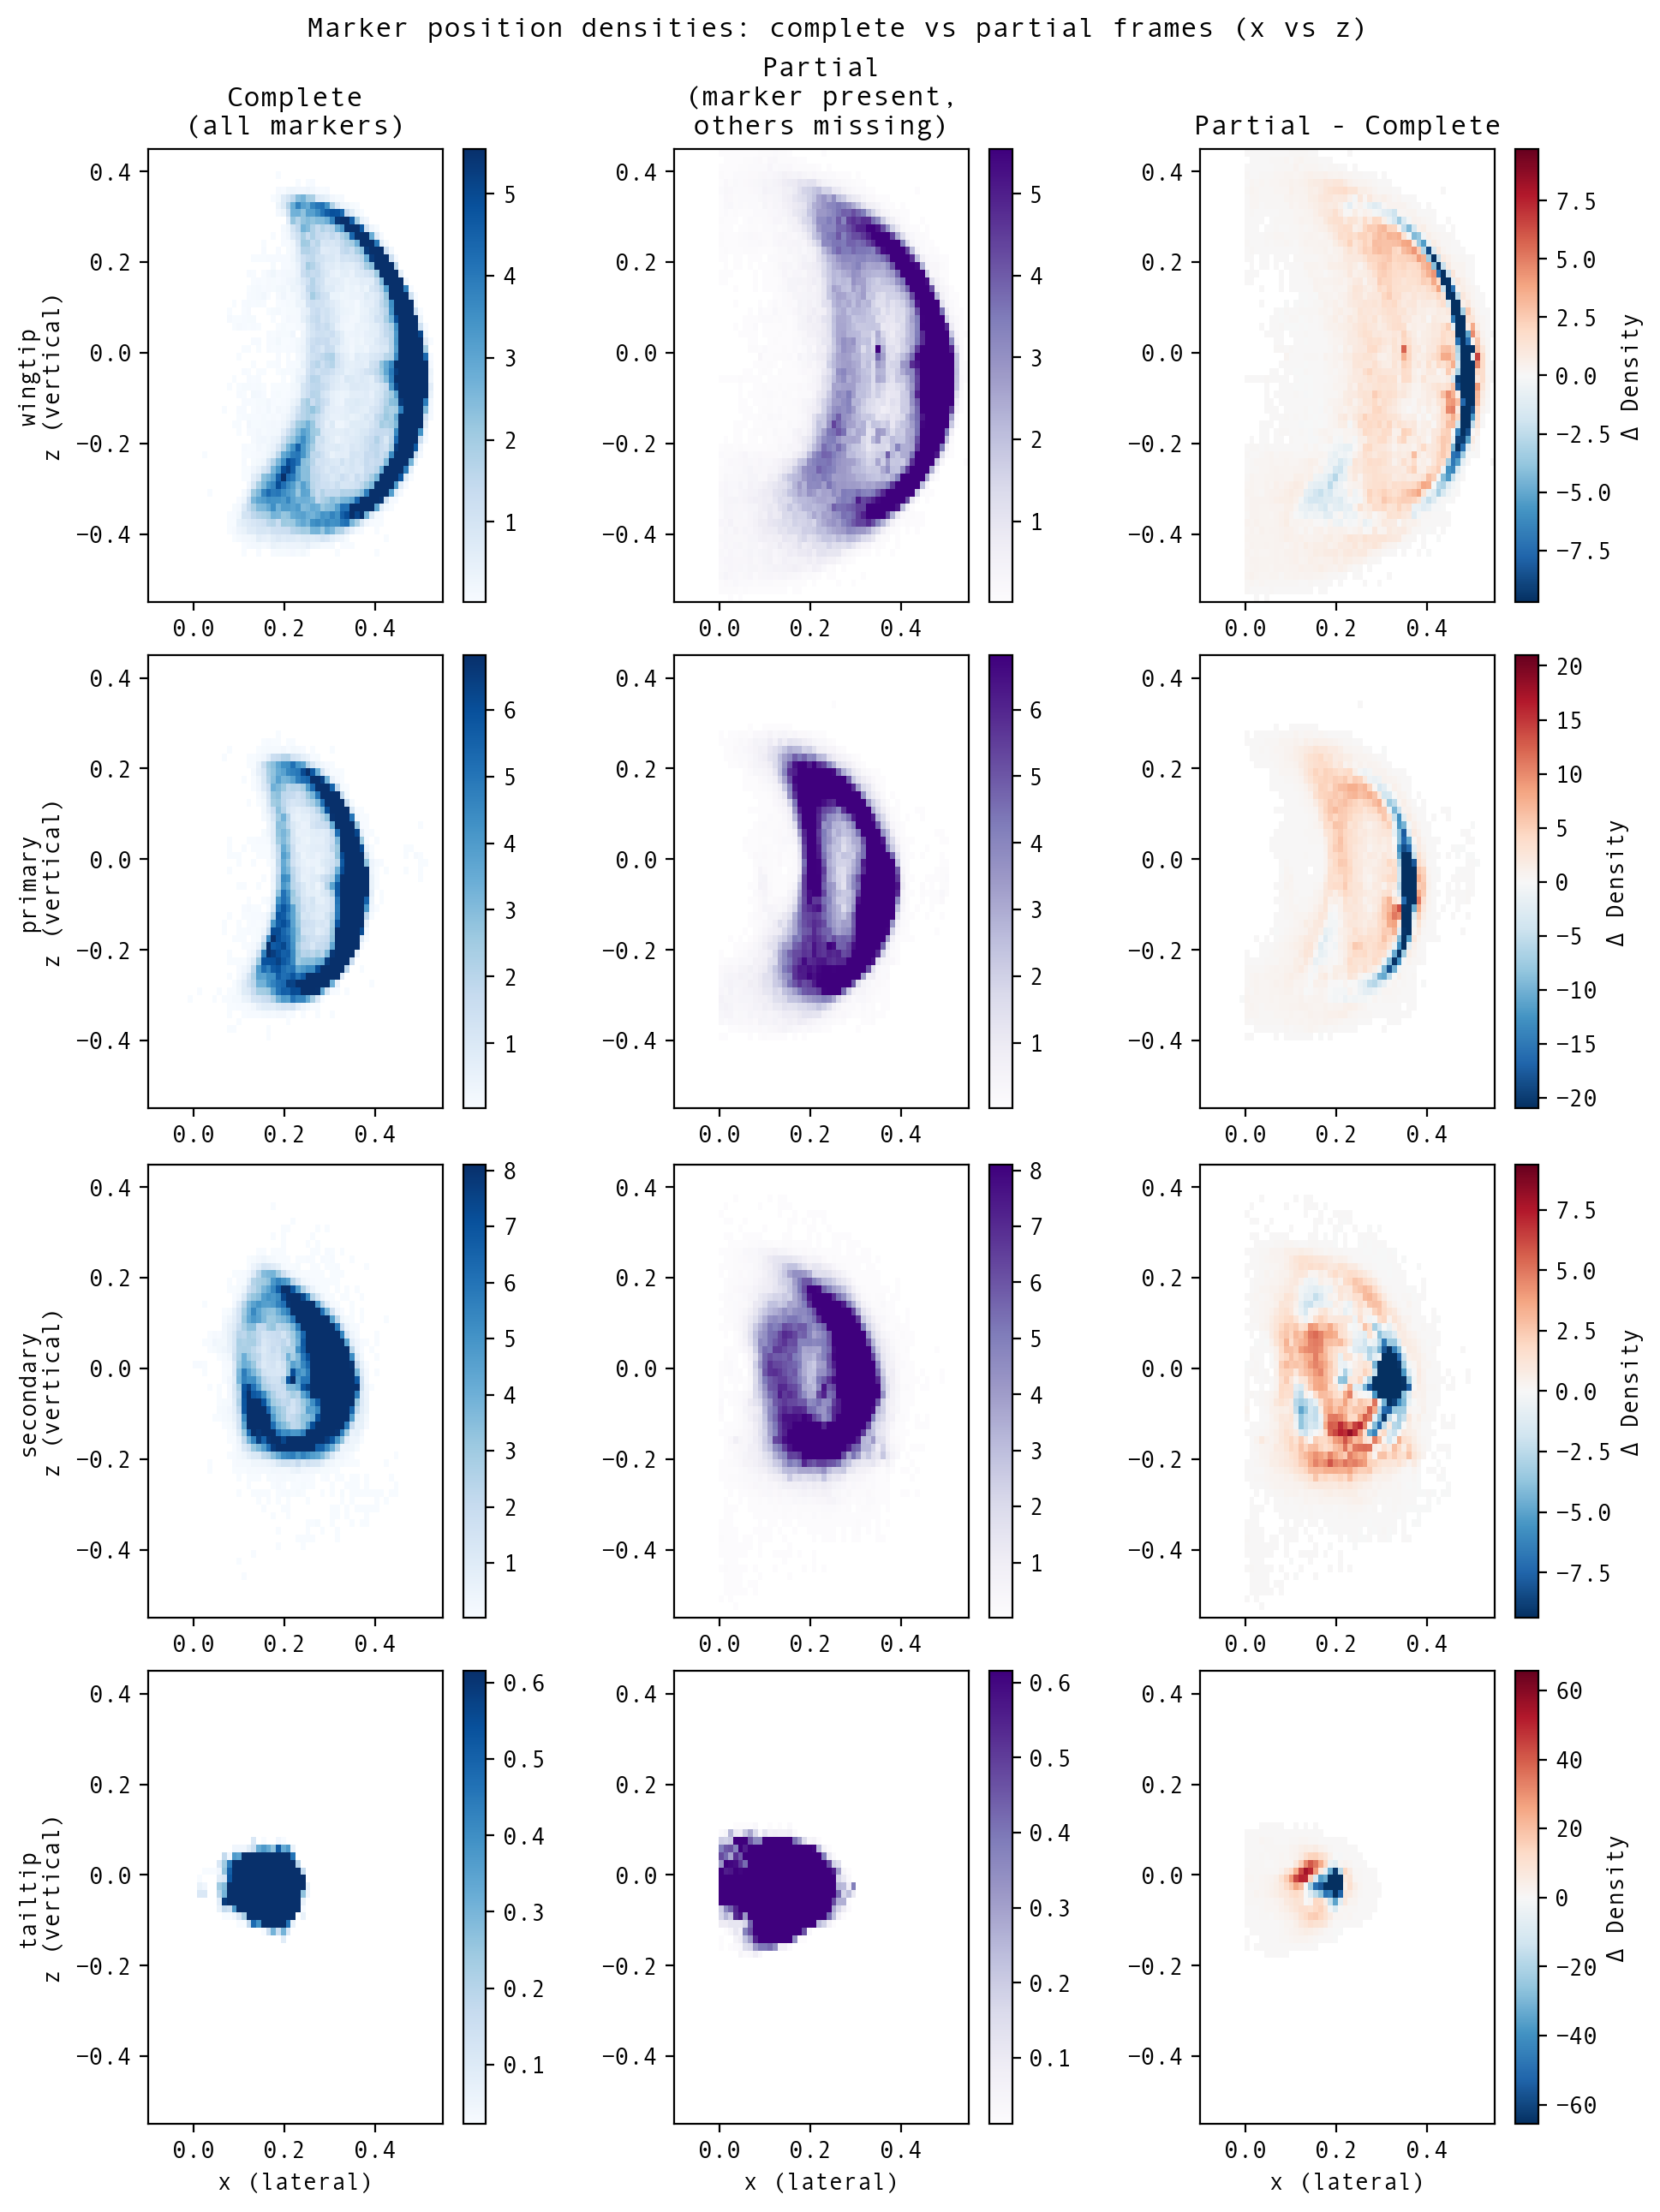

In [6]:
# --- x vs z (lateral vs vertical) ---
fig_xz = plot_density_comparison(
    complete_unilateral, partial_unilateral, MARKER_NAMES,
    coord_a=0, coord_b=2,
    label_a='x (lateral)', label_b='z (vertical)',
    suptitle='Marker position densities: complete vs partial frames (x vs z)',
)
save_figure(fig_xz, str(FIGURE_DIR / 'S15_density_xz.pdf'))
plt.show()

Saved: ../../figures/supplementary/S15_density_xy.pdf


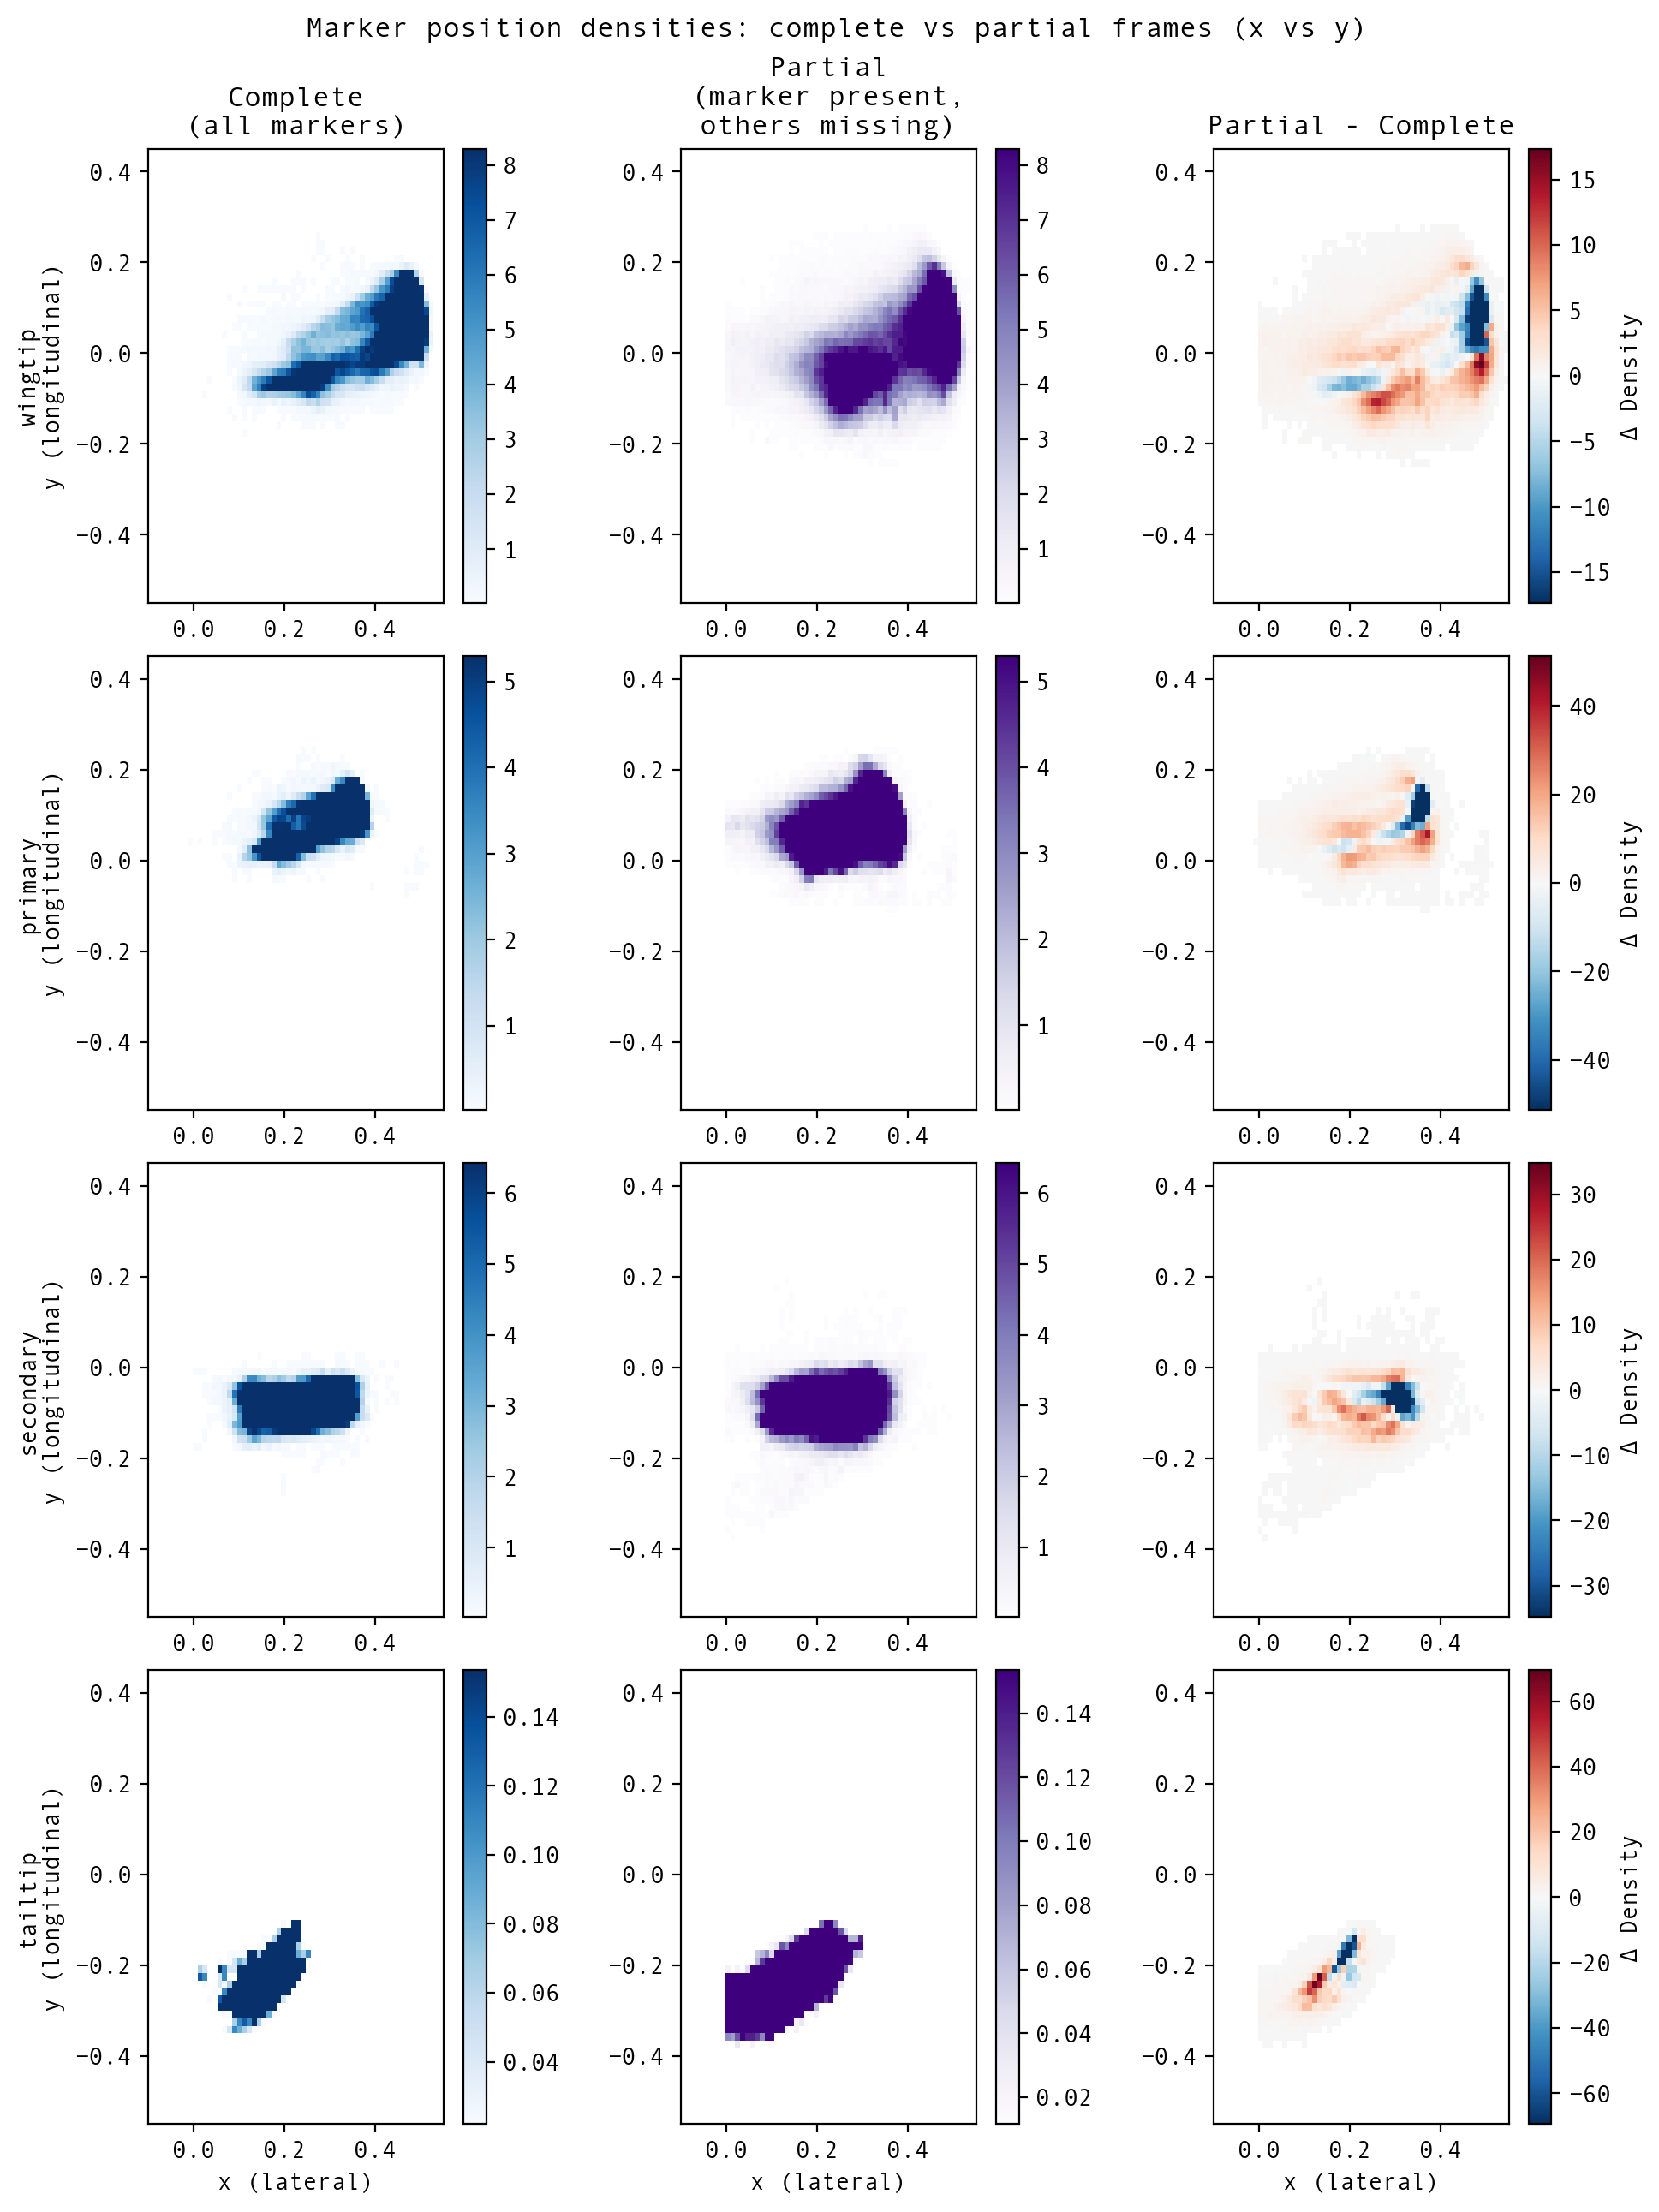

In [7]:
# --- x vs y (lateral vs longitudinal) ---
fig_xy = plot_density_comparison(
    complete_unilateral, partial_unilateral, MARKER_NAMES,
    coord_a=0, coord_b=1,
    label_a='x (lateral)', label_b='y (longitudinal)',
    suptitle='Marker position densities: complete vs partial frames (x vs y)',
)
save_figure(fig_xy, str(FIGURE_DIR / 'S15_density_xy.pdf'))
plt.show()

**Note on mislabelling:** In the wingtip row, the difference panel shows isolated peaks in regions where wingtip markers should not occur -- these indicate that some labelled wingtip markers are actually primary-feather markers, evidence of mislabelling by the reconstruction pipeline. NB06 shows that the PCA results are robust to such labelling noise, but the artefacts are visible here.

**Summary:** While complete and partial frames differ in density (19–26 percentage point shift away from the gliding peak), the overall spatial structure is consistent. Both datasets cover the same regions of coordinate space; the difference is in how densely each region is sampled.

## §15.3 Occlusion Robustness

The density comparison shows that complete and partial frames differ in *where* they sample coordinate space -- complete frames cluster at gliding configurations, partial frames spread more uniformly into folded-wing regions. But spatial density is not the same as morphospace structure. The question is whether those undersampled configurations occupy a *different* morphing subspace, or whether they follow the same low-dimensional structure with different sampling density.

Three tests address this:

1. **Occlusion-conditioned PCA** -- Compare PCA bases computed from complete frames versus frames where a marker is naturally occluded. If the morphing structure is the same, the bases will align.
2. **Projection validation** -- Verify that estimating PC scores from partial markers (via least-squares projection) is accurate enough to trust the subsequent coverage analysis.
3. **Coverage comparison** -- Check whether partial frames visit regions of coordinate space that complete frames miss entirely, or merely resample the same space with different density.

### Occlusion-Conditioned PCA

The previous dropout analysis shows *which* shapes are undersampled but not whether those frames occupy a *different* morphing space. To test this directly without imputation, we compare PCA bases computed from two groups of real marker positions:

- **Group A (complete, marker dropped):** All 126k complete straight-flight frames, with one marker removed -- the previously described marker-subsetting test (NB06 §14.6).
- **Group B (naturally occluded):** Frames from the 559k dataset where that marker is genuinely missing but all others are present.

If occlusion is associated with a different region of morphing space, the PCA from Group B will differ from Group A. If the morphing structure is the same regardless of occlusion, the bases will align. This uses only real measured positions with no imputation or reconstruction.

Given the constraints of the motion capture recordings, we would expect the most folded configurations to have lower number of frames. It could be other configurations are also unrepresented. 

In [8]:
# --- Compare PCA bases: complete frames vs naturally occluded frames ---
# For each marker, fit independent PCAs on:
#   Group A: complete frames with that marker artificially removed
#   Group B: frames where that marker is genuinely missing (others present)
marker_names = ["wingtip", "primary", "secondary", "tailtip"]

occlusion_rows = []
for drop_idx, drop_name in enumerate(marker_names):
    keep = [i for i in range(4) if i != drop_idx]

    # Group A: all complete unilateral frames, one marker dropped
    flat_complete = get_PCA_input(complete_unilateral[:, keep, :])
    flat_complete_centred = flat_complete - flat_complete.mean(axis=0)
    _, _, pca_complete = run_PCA(flat_complete_centred, flat_input=True, n_components=min(9, flat_complete.shape[1]))

    # Group B: 559k frames where target marker is missing, others present
    target_missing = np.isnan(partial_unilateral[:, drop_idx, 0])
    others_present = np.all(~np.isnan(partial_unilateral[:, keep, 0]), axis=1)
    occluded_mask = target_missing & others_present

    if occluded_mask.sum() < 100:
        occlusion_rows.append(dict(
            marker=drop_name, n_occluded=int(occluded_mask.sum()),
            cev_complete=0, cev_occluded=0, cosines=None,
        ))
        continue

    flat_occluded = get_PCA_input(partial_unilateral[occluded_mask][:, keep, :])
    flat_occluded_centred = flat_occluded - flat_occluded.mean(axis=0)
    _, _, pca_occluded = run_PCA(flat_occluded_centred, flat_input=True, n_components=min(9, flat_occluded.shape[1]))

    # Compare subspaces via principal cosines
    n_compare = min(4, pca_complete.n_components_, pca_occluded.n_components_)
    cosines = principal_cosines(
        pca_complete.components_[:n_compare].T,
        pca_occluded.components_[:n_compare].T,
        modes=n_compare,
    )
    cev_complete = np.cumsum(pca_complete.explained_variance_ratio_)[min(3, pca_complete.n_components_ - 1)]
    cev_occluded = np.cumsum(pca_occluded.explained_variance_ratio_)[min(3, pca_occluded.n_components_ - 1)]

    occlusion_rows.append(dict(
        marker=drop_name, n_occluded=int(occluded_mask.sum()),
        cev_complete=cev_complete, cev_occluded=cev_occluded,
        cosines=cosines,
    ))

print_occlusion_pca(occlusion_rows)


Dropped        Occluded       ── CEV₄ ──          Cosines (modes 1-4)   
marker           frames    Complete  Occluded       1      2      3      4
────────────────────────────────────────────────────────────────────
wingtip          57,861      0.9533    0.9220   0.999  0.994  0.909  0.156
primary         105,957      0.9675    0.9554   1.000  0.999  0.984  0.961
secondary        60,376      0.9746    0.9659   1.000  0.999  0.998  0.959
tailtip          44,817      0.9771    0.9448   1.000  1.000  0.995  0.308


**Interpretation.** The dominant morphing modes (1–2) are virtually identical whether computed from complete frames or from frames where a marker is naturally occluded (cosines >0.99 in all cases). This confirms that marker occlusion does not select for a different region of morphing space -- the same low-dimensional structure governs wing-tail shape regardless of which markers happen to be visible.

Mode 3 shows slight divergence (cosine 0.909) when the wingtip is occluded, but is otherwise similar to the complete-frame version. Mode 4 is not reproduced when the tailtip or wingtip is missing. Nevertheless, the subspace spanned by the first two modes (which together capture >90% of variance) is effectively invariant to natural occlusion patterns. 

Together with the dropout analysis (above), these results show that the complete-marker subset undersamples folded-wing configurations by ~20 percentage points but that those configurations occupy the same morphing space as the rest of the data. The bias affects sampling density, not the morphing structure itself.

### Projection Validation

The occlusion bias test relies below on scoring partial frames via least-squares projection -- estimating PC1 and PC2 from whichever markers are visible. Before interpreting those results, we need to know how much error this introduces. If the projection is noisy enough to wash out real shifts, or biased enough to create false ones, the histogram comparison in the coverage comparison cannot be trusted.

We test this on the complete data where the true scores are known. For each frame, we mask one or two markers (simulating the real missing-data pattern), estimate PC1 and PC2 from the remaining markers, and compare against the true scores. The RMSE and correlation quantify the projection error.

In [9]:
# Fit the full unilateral PCA (all 4 markers, matching the paper pipeline)
flat_unilateral = get_PCA_input(complete_unilateral)
mu_unilateral = flat_unilateral.mean(axis=0)
_, _, pca_unilateral = run_PCA(flat_unilateral - mu_unilateral, flat_input=True, n_components=4)
components = pca_unilateral.components_  # (4, 12)

# True scores with all 4 markers
true_scores = pca_unilateral.transform(flat_unilateral - mu_unilateral)
loadings = components[:2].T  # (12, 2) loadings for modes 1-2

marker_names = ["wingtip", "primary", "secondary", "tailtip"]

def _projection_row(label, observed_cols):
    loadings_obs = loadings[observed_cols, :]
    x_observed = flat_unilateral[:, observed_cols] - mu_unilateral[observed_cols]
    estimated = x_observed @ loadings_obs @ np.linalg.inv(loadings_obs.T @ loadings_obs)
    return dict(
        label=label,
        rmse_pc1=np.sqrt(np.mean((true_scores[:, 0] - estimated[:, 0])**2)),
        rmse_pc2=np.sqrt(np.mean((true_scores[:, 1] - estimated[:, 1])**2)),
        corr_pc1=np.corrcoef(true_scores[:, 0], estimated[:, 0])[0, 1],
        corr_pc2=np.corrcoef(true_scores[:, 1], estimated[:, 1])[0, 1],
    )

proj_rows = []

# One marker masked
for marker_idx, marker_name in enumerate(marker_names):
    observed = [c for c in range(12) if c // 3 != marker_idx]
    proj_rows.append(_projection_row(marker_name, observed))

proj_rows.append({"separator": True})

# Two markers masked
for (idx_a, name_a), (idx_b, name_b) in itertools.combinations(enumerate(marker_names), 2):
    observed = [c for c in range(12) if c // 3 != idx_a and c // 3 != idx_b]
    proj_rows.append(_projection_row(f"{name_a} + {name_b}", observed))

print_projection_validation(
    n_frames=flat_unilateral.shape[0],
    pc1_sd=true_scores[:, 0].std(),
    pc2_sd=true_scores[:, 1].std(),
    rows=proj_rows,
)


Least-squares projection validation
Frames: 252,630  |  PC1 SD: 0.2193  |  PC2 SD: 0.1342

Masked                    PC1 RMSE  PC2 RMSE   PC1 r   PC2 r
───────────────────────────────────────────────────────
wingtip                     0.0261    0.0227  0.9930  0.9859
primary                     0.0139    0.0089  0.9980  0.9978
secondary                   0.0091    0.0119  0.9991  0.9961
tailtip                     0.0009    0.0044  1.0000  0.9995

wingtip + primary           0.0500    0.0390  0.9749  0.9602
wingtip + secondary         0.0391    0.0370  0.9845  0.9639
wingtip + tailtip           0.0260    0.0231  0.9931  0.9855
primary + secondary         0.0184    0.0180  0.9965  0.9911
primary + tailtip           0.0140    0.0114  0.9980  0.9964
secondary + tailtip         0.0091    0.0117  0.9991  0.9962


**Interpretation.** The projection seems accurate. With one marker masked, correlations exceed 0.99 for both PC1 and PC2 across all markers. With two markers masked (the worst case for the partial frames used in the coverage comparison) the minimum correlation is 0.96 (wingtip + primary missing), with RMSE at ~23% of the score SD. The projection introduces noise but not systematic bias, so the distribution shifts observed in the coverage comparison reflect genuine differences in wing shape between complete and partial frames, not artefacts of the scoring method.

### Coverage: Do Partial Frames Visit New Regions?

Having established that the dominant morphing modes are shared regardless of marker occlusion (above), we now ask whether partial frames visit *new regions* of coordinate space that complete frames miss entirely. We bin each marker's raw positions (x vs z) and classify each bin as shared (both datasets), complete-only, or novel (partial-only). If partial frames merely resample the same region with different density, the novel fraction will be negligible.

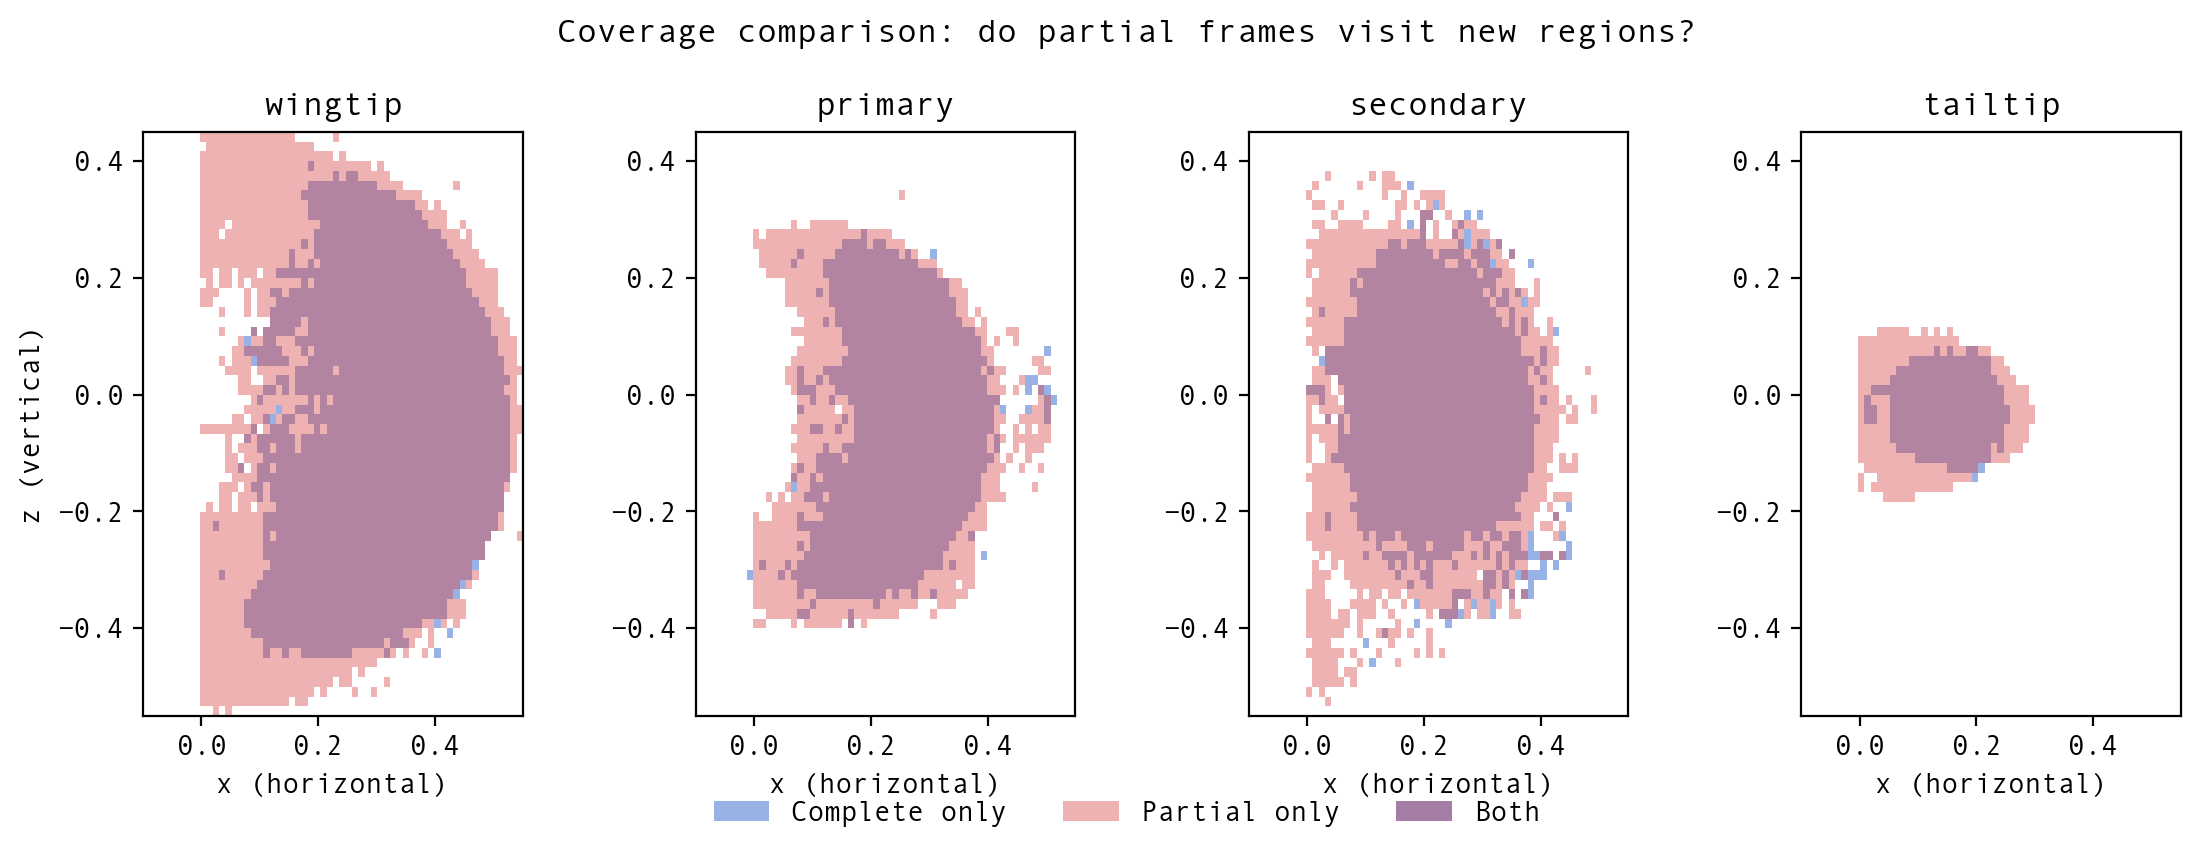

   Marker  Shared  Complete only  Partial only Partial-only bins % Frames in novel %
  wingtip    1504             10           800               34.6%              2.7%
  primary     836             12           480               36.1%              2.0%
secondary     897             38           599               39.0%              1.6%
  tailtip     200              2           184               47.7%              1.7%


In [10]:
# --- Coverage comparison: do partial frames visit new regions? ---
fig, coverage_stats = plot_coverage_comparison(
    complete_unilateral, partial_unilateral, MARKER_NAMES, bins=60
)
plt.show()

# Summary table
print(pd.DataFrame(coverage_stats).to_string(index=False))

**Interpretation.** The coverage comparison shows that there are 35–48% of bins only covered by partial frames. These novel bins however are sparsely populated: only 1.6–2.7% of partial frames fall in regions that complete frames never visit. The remaining ~97% of partial frames occupy the same coordinate-space regions as complete frames, just with different density. It is possible that some of the novel bins are artefacts of mislabelling or artefacts (ghost reflections picked up by the motion capture system) rather than genuine configurations, but even if all novel bins were real, they represent a small fraction of the data.

The bias between complete and partial frames is therefore primarily in sampling density. Complete frames overrepresent gliding and spread-wing configurations -- when all markers are most visible to overhead cameras -- while partial frames populate folded-wing and flapping-extreme regions more uniformly. The small fraction of frames in truly novel regions suggests that the complete-marker dataset captures the relevant morphospace structure, even if it undersamples certain postures.

## Matrix Completion — cross-ref NB06 §14.10 — cross-ref NB06 §14.10

The occlusion tests above demonstrate that partial frames occupy the same morphospace as complete frames and the bias is in sampling density, not structure. But those tests compare subsets of the data: frames where all markers are present versus frames where at least one is missing.

An alternative approach is to reconstruct the missing markers via imputation and run PCA on the imputed dataset. If the low-dimensional structure is genuine, it should persist even when we impute the missing markers in 669k partial frames. If it were an artefact of which postures happened to have full marker visibility, the structure would collapse or shift.

We use multivariate imputation by chained equations (MICE), which makes no assumption about global low-rank structure. This avoids the circularity of using PCA-based imputation (e.g. EM-PCA) to validate a PCA result.

> _van Buuren, Stef. "Multiple Imputation of Discrete and Continuous Data by Fully Conditional Specification." Statistical methods in medical research 16.3 (2007): 219–242._
>
> _Azur, Melissa J et al. "Multiple Imputation by Chained Equations: What Is It and How Does It Work?" International Journal of Methods in Psychiatric Research 20.1 (2011): 40–49._

In [11]:
# --- Matrix completion via MICE imputation ---
# partial_unilateral already contains straight-flight frames (936,806 unilateral)
n_partial = partial_unilateral.shape[0]

# Flatten to (n_frames, 12) for imputation
partial_flat = partial_unilateral.reshape(n_partial, -1)

# Calculate per-marker dropout rates
dropout_rates = {}
for m, name in enumerate(MARKER_NAMES):
    missing_count = np.isnan(partial_unilateral[:, m, 0]).sum()
    dropout_rates[name] = missing_count / n_partial

# Fit MICE imputer (BayesianRidge, no PCA assumption)
rng = ensure_rng(CONFIG["rng_seed"])
imputer = IterativeImputer(
    max_iter=100,
    tol=1e-3,
    random_state=rng.integers(2**31),
)
imputed_flat = imputer.fit_transform(partial_flat)
imputed_data = imputed_flat.reshape(n_partial, 4, 3)

print(f"Imputed {n_partial:,} frames with {np.isnan(partial_flat).sum():,} missing values")

Imputed 669,212 frames with 2,958,465 missing values


/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/kinematic-morphospace/.venv/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [12]:
# --- Cross-validation: assess imputation accuracy ---
# Randomly mask 10% of observed entries, re-impute, compare to true values
cv_rng = ensure_rng(CONFIG["rng_seed"] + 1)
observed_mask = ~np.isnan(partial_flat)
n_observed = observed_mask.sum()
n_holdout = int(0.10 * n_observed)

# Sample indices of observed entries to hold out
observed_indices = np.argwhere(observed_mask)
holdout_idx = cv_rng.choice(len(observed_indices), size=n_holdout, replace=False)
holdout_coords = observed_indices[holdout_idx]

# Create masked copy for CV imputation
cv_flat = partial_flat.copy()
true_values = np.array([partial_flat[r, c] for r, c in holdout_coords])
for r, c in holdout_coords:
    cv_flat[r, c] = np.nan

# Re-impute with held-out entries
cv_imputer = IterativeImputer(max_iter=100, tol=1e-3, random_state=cv_rng.integers(2**31))
cv_imputed = cv_imputer.fit_transform(cv_flat)
predicted_values = np.array([cv_imputed[r, c] for r, c in holdout_coords])

# RMSE in metres and as percentage of mean wingspan
cv_rmse = np.sqrt(np.mean((true_values - predicted_values)**2))
import yaml
from pathlib import Path
_ws_path = Path('../../src/kinematic_morphospace/TotalWingspans.yml')
with open(_ws_path) as _f:
    _ws = yaml.safe_load(_f)
mean_wingspan = np.mean([v for bird in _ws.values() for v in bird.values()])
cv_rmse_pct = 100 * cv_rmse / mean_wingspan

print(f"Cross-validation (10% held out):")
print(f"  RMSE: {cv_rmse:.4f} m ({cv_rmse_pct:.1f}% of mean wingspan)")

/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/kinematic-morphospace/.venv/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Cross-validation (10% held out):
  RMSE: 0.0521 m (5.0% of mean wingspan)


In [13]:
# --- PCA comparison: baseline vs imputed ---
# Baseline: complete straight-flight frames
baseline_flat = get_PCA_input(complete_unilateral)
_, _, pca_baseline = run_PCA(baseline_flat, flat_input=True, n_components=12)
cev_baseline = np.cumsum(pca_baseline.explained_variance_ratio_)

# Imputed: full straight-flight dataset after MICE completion
imputed_flat_pca = get_PCA_input(imputed_data)
_, _, pca_imputed = run_PCA(imputed_flat_pca, flat_input=True, n_components=12)
cev_imputed = np.cumsum(pca_imputed.explained_variance_ratio_)

# Principal cosines between baseline and imputed subspaces
n_modes = 4
cosines = principal_cosines(
    pca_baseline.components_[:n_modes].T,
    pca_imputed.components_[:n_modes].T,
    modes=n_modes,
)

# Print summary
print_imputation_results(
    n_frames_complete=complete_unilateral.shape[0],
    n_frames_imputed=n_partial,
    dropout_rates=dropout_rates,
    cv_rmse=cv_rmse,
    cv_rmse_pct=cv_rmse_pct,
    cev_complete=cev_baseline,
    cev_imputed=cev_imputed,
    cosines=cosines,
    n_modes=n_modes,
)

Matrix Completion Results

Datasets:
  Complete-marker baseline:    252,630 frames
  Imputed dataset:             669,212 frames
  Expansion factor:                2.6×

Per-marker dropout rates:
  wingtip     : 36.1%
  primary     : 46.2%
  secondary   : 36.4%
  tailtip     : 28.7%

Imputation accuracy (10% held-out cross-validation):
  RMSE: 0.0521 m (5.0% of mean wingspan)

PCA comparison:
              Mode 1  Mode 2  Mode 3  Mode 4
  ------------------------------------------
  CEV         66.6%  91.5%  94.2%  96.3%  (baseline)
              64.8%  87.8%  93.8%  95.5%  (imputed)
  Cosines     0.9998  0.9993  0.9645  0.8613


Saved: ../../figures/supplementary/S15_imputation_validation.pdf


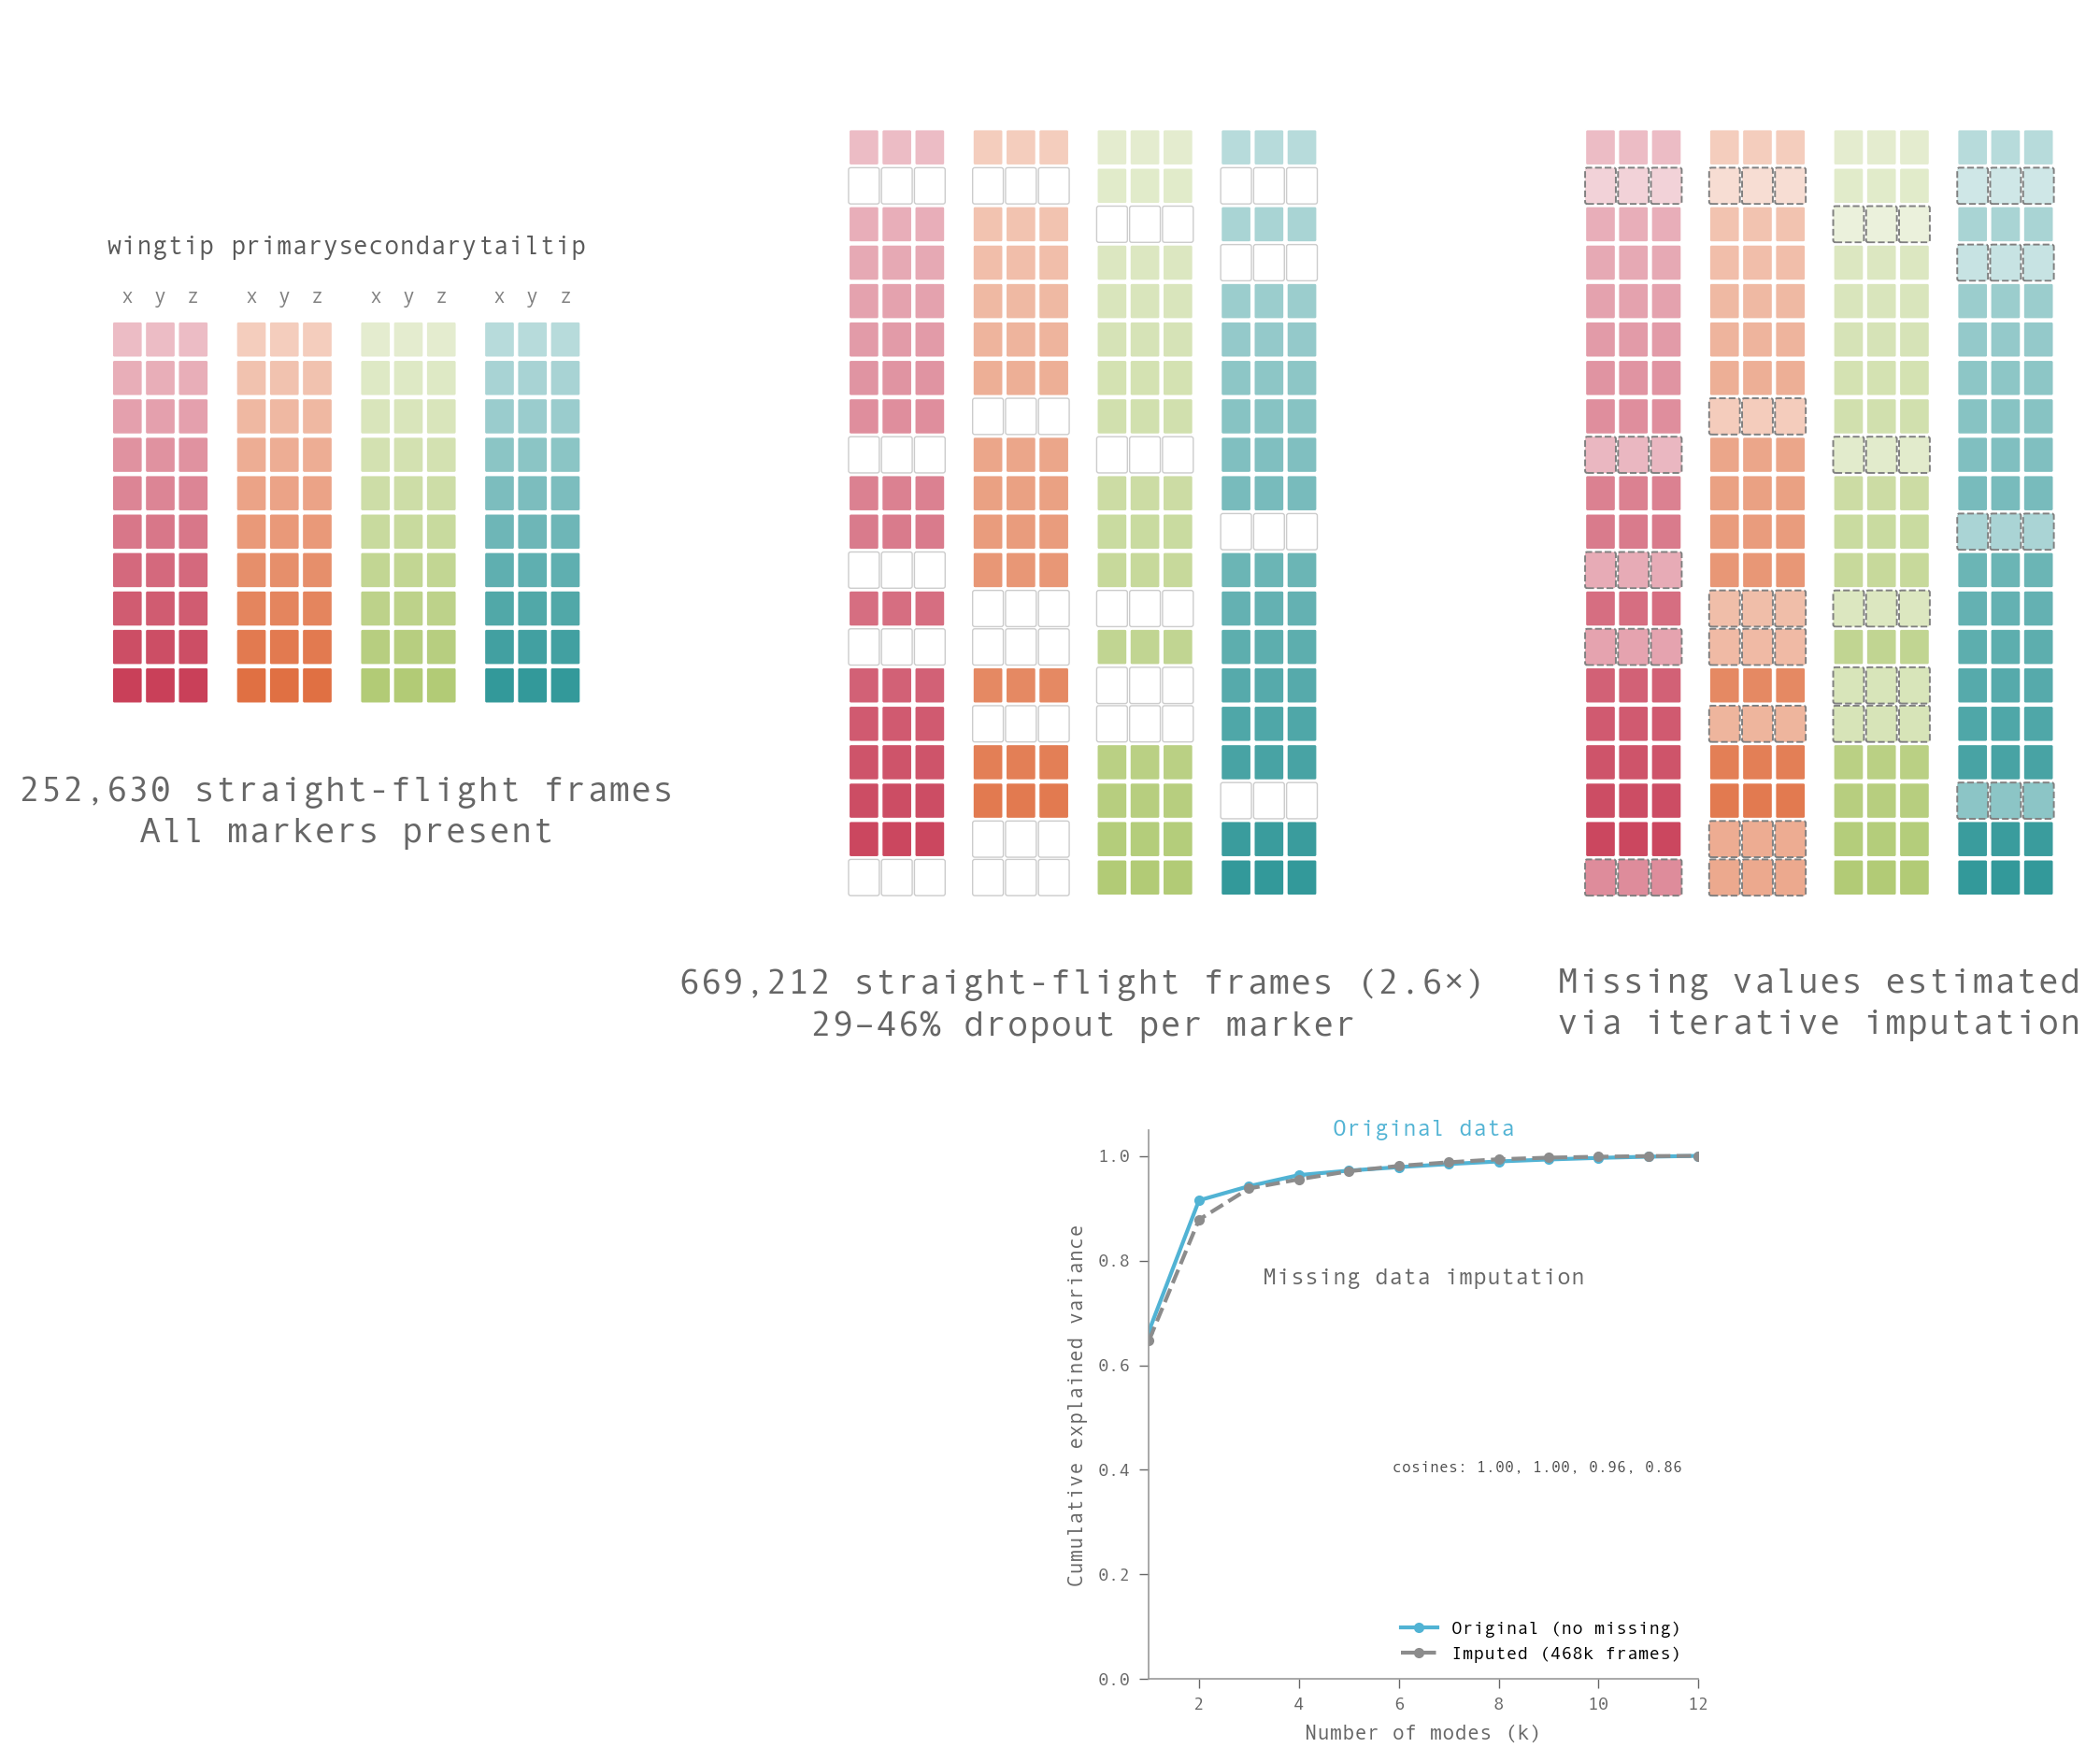

In [14]:
# --- Composite figure ---
fig = plot_imputation_composite(cev_baseline, cev_imputed, cosines, n_comp=12)
save_figure(fig, str(FIGURE_DIR / 'S15_imputation_validation.pdf'))
plt.show()

**Interpretation.** The imputed dataset has reconstruction error within 5% of the total wingspan using held out frames as verification. PCA performed on the imputed dataset recovered the same steep variance decline as the complete-frames dataset. Principal-cosine analysis confirmed the modes align closely. The first three modes are near-identical; the fourth shows moderate alignment, reflecting sensitivity of lower-variance modes to imputation noise. These results support evidence that the low-dimensional morphing space is not an artefact of frame selection and that hawks' wing-tail geometry is inherently low-rank.

We do not use the imputed dataset for further analysis; it serves only as a robustness check.

**Method detail:** MICE (scikit-learn's `IterativeImputer`) iteratively models each feature as a function of all others, imputing missing values one column at a time and cycling until convergence. Unlike EM-PCA, which fits a single low-rank model globally, MICE fits a separate regression per feature -- making it more flexible and, crucially, not constrained to a PCA-like subspace a priori.

## §15.4 Marker Dropout Patterns and Mislabelling Detection

The previous sections establish that sampling bias affects density, not structure. But understanding whether the missingness of maker drop-out is random or systematic provides additional insight into the motion-capture limitations and potential mislabelling issues.

This section explores the structure of missingness: which markers drop out most often, whether dropout of one marker predicts dropout of another, and where the remaining markers are positioned when a specific marker disappears. These patterns reveal whether dropout is posture-dependent (e.g. wingtip hidden during wing folding) or random measurement failure.

### Dropout rates and co-occurrence

In [15]:
# --- Per-marker dropout rates ---
print_marker_dropout_rates(MARKER_NAMES, partial_unilateral)

Marker dropout rates in partial frames:
Marker          Missing    Present  Dropout %
---------------------------------------------
wingtip         241,844    427,368      36.1%
primary         309,223    359,989      46.2%
secondary       243,279    425,933      36.4%
tailtip         191,809    477,403      28.7%


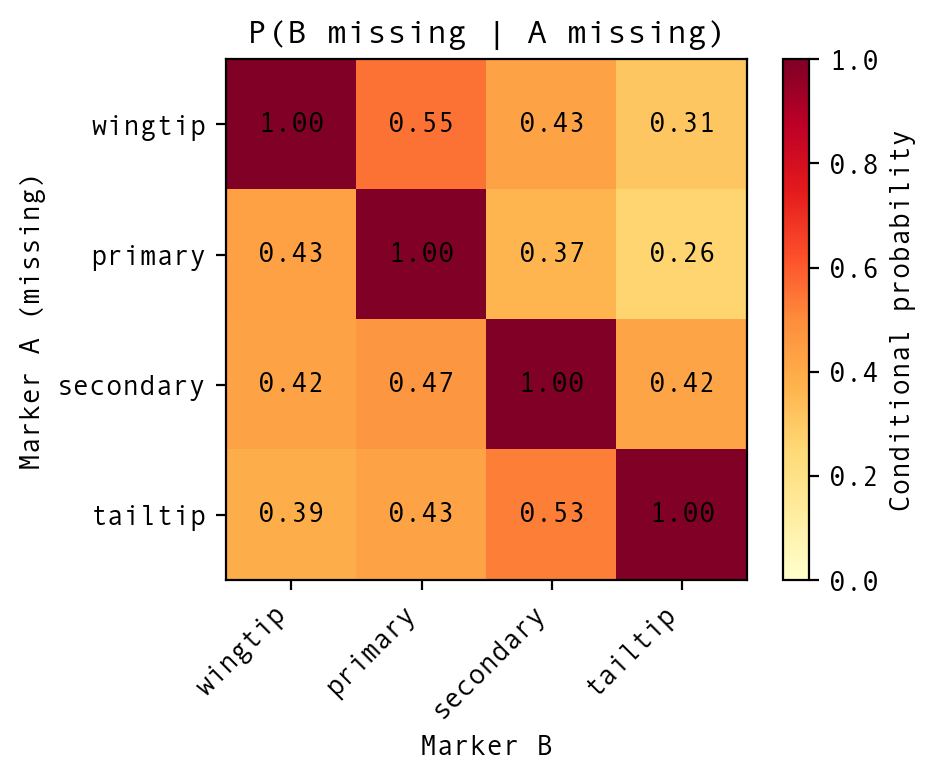

In [16]:
# --- Co-occurrence of missingness ---
fig, co_occur = plot_cooccurrence_heatmap(partial_unilateral, MARKER_NAMES)
plt.show()

In [17]:
# --- Per-hawk dropout rates ---
partial_info_straight = partial_info[straight_missing].iloc[any_nan_bilateral].reset_index(drop=True)
bilateral_left_idx = [0, 2, 4, 6]

print_per_hawk_dropout(
    partial_bilateral, partial_info_straight, hawk_names,
    MARKER_NAMES, bilateral_left_idx
)

      Hawk  Period  Frames Partial % wingtip % primary % secondary % tailtip %
    Drogon       1   81628    100.0%     32.9%     56.9%       45.3%     32.4%
    Drogon       2   17836    100.0%     43.3%     52.0%       25.8%     27.6%
   Rhaegal       1   68810    100.0%     39.6%     35.2%       45.6%     27.7%
      Ruby       1   41407    100.0%     41.1%     28.1%       24.0%     35.2%
      Ruby       2   24696    100.0%     36.3%     64.3%       17.9%     32.7%
 Toothless       1   70611    100.0%     28.1%     62.8%       28.9%     23.6%
 Toothless       2   13969    100.0%     42.7%     34.9%       33.7%     42.2%
Charmander       2   15649    100.0%     26.8%     13.3%       53.1%     14.2%


**Interpretation.** Dropout rates vary substantially across individuals and recording periods. The primary marker has consistently high dropout (28–64%), reflecting its distal position on the wing where feathers frequently occlude the marker during wingbeats. Notably, dropout patterns differ between hawks: Drogon and Toothless in Period 1 show high primary dropout (~57–63%), while Charmander in Period 2 shows unusually low primary dropout (13%) but high secondary dropout (53%). These individual differences likely reflect variation in marker placement, feather coverage, and flight style rather than systematic camera bias.

The co-occurrence heatmap shows P(B missing | A missing) or the probability that marker B is missing given that marker A is missing. Off-diagonal values around 0.4–0.6 indicate moderate co-dropout: when one marker disappears, others often do too. This reflects shared postural causes (wing folding occludes multiple markers simultaneously) rather than independent marker failures. The diagonal is 1.0 by definition.

### Where are the other markers when one drops out?

For each target marker that is missing, we plot the positions of the *remaining* markers that are still visible. This reveals whether dropout is posture-dependent -- e.g. the wingtip disappears when wings are folded.

Each row corresponds to one marker being missing (row label = the dropped marker). The three columns show where the *other* markers are:

- **Blue (left column):** Baseline -- positions of other markers in complete frames (all 4 visible).
- **Purple (middle column):** Dropout -- positions of other markers when the row's target marker is missing.
- **Red–blue difference (right column):** Where dropout frames are more common (red) vs less common (blue). Red regions indicate postures that preferentially lose the target marker.

wingtip missing (others present): 57,861 frames
primary missing (others present): 105,957 frames
secondary missing (others present): 60,376 frames
tailtip missing (others present): 44,817 frames
Saved: ../../figures/supplementary/S15_dropout_positions_xz.pdf


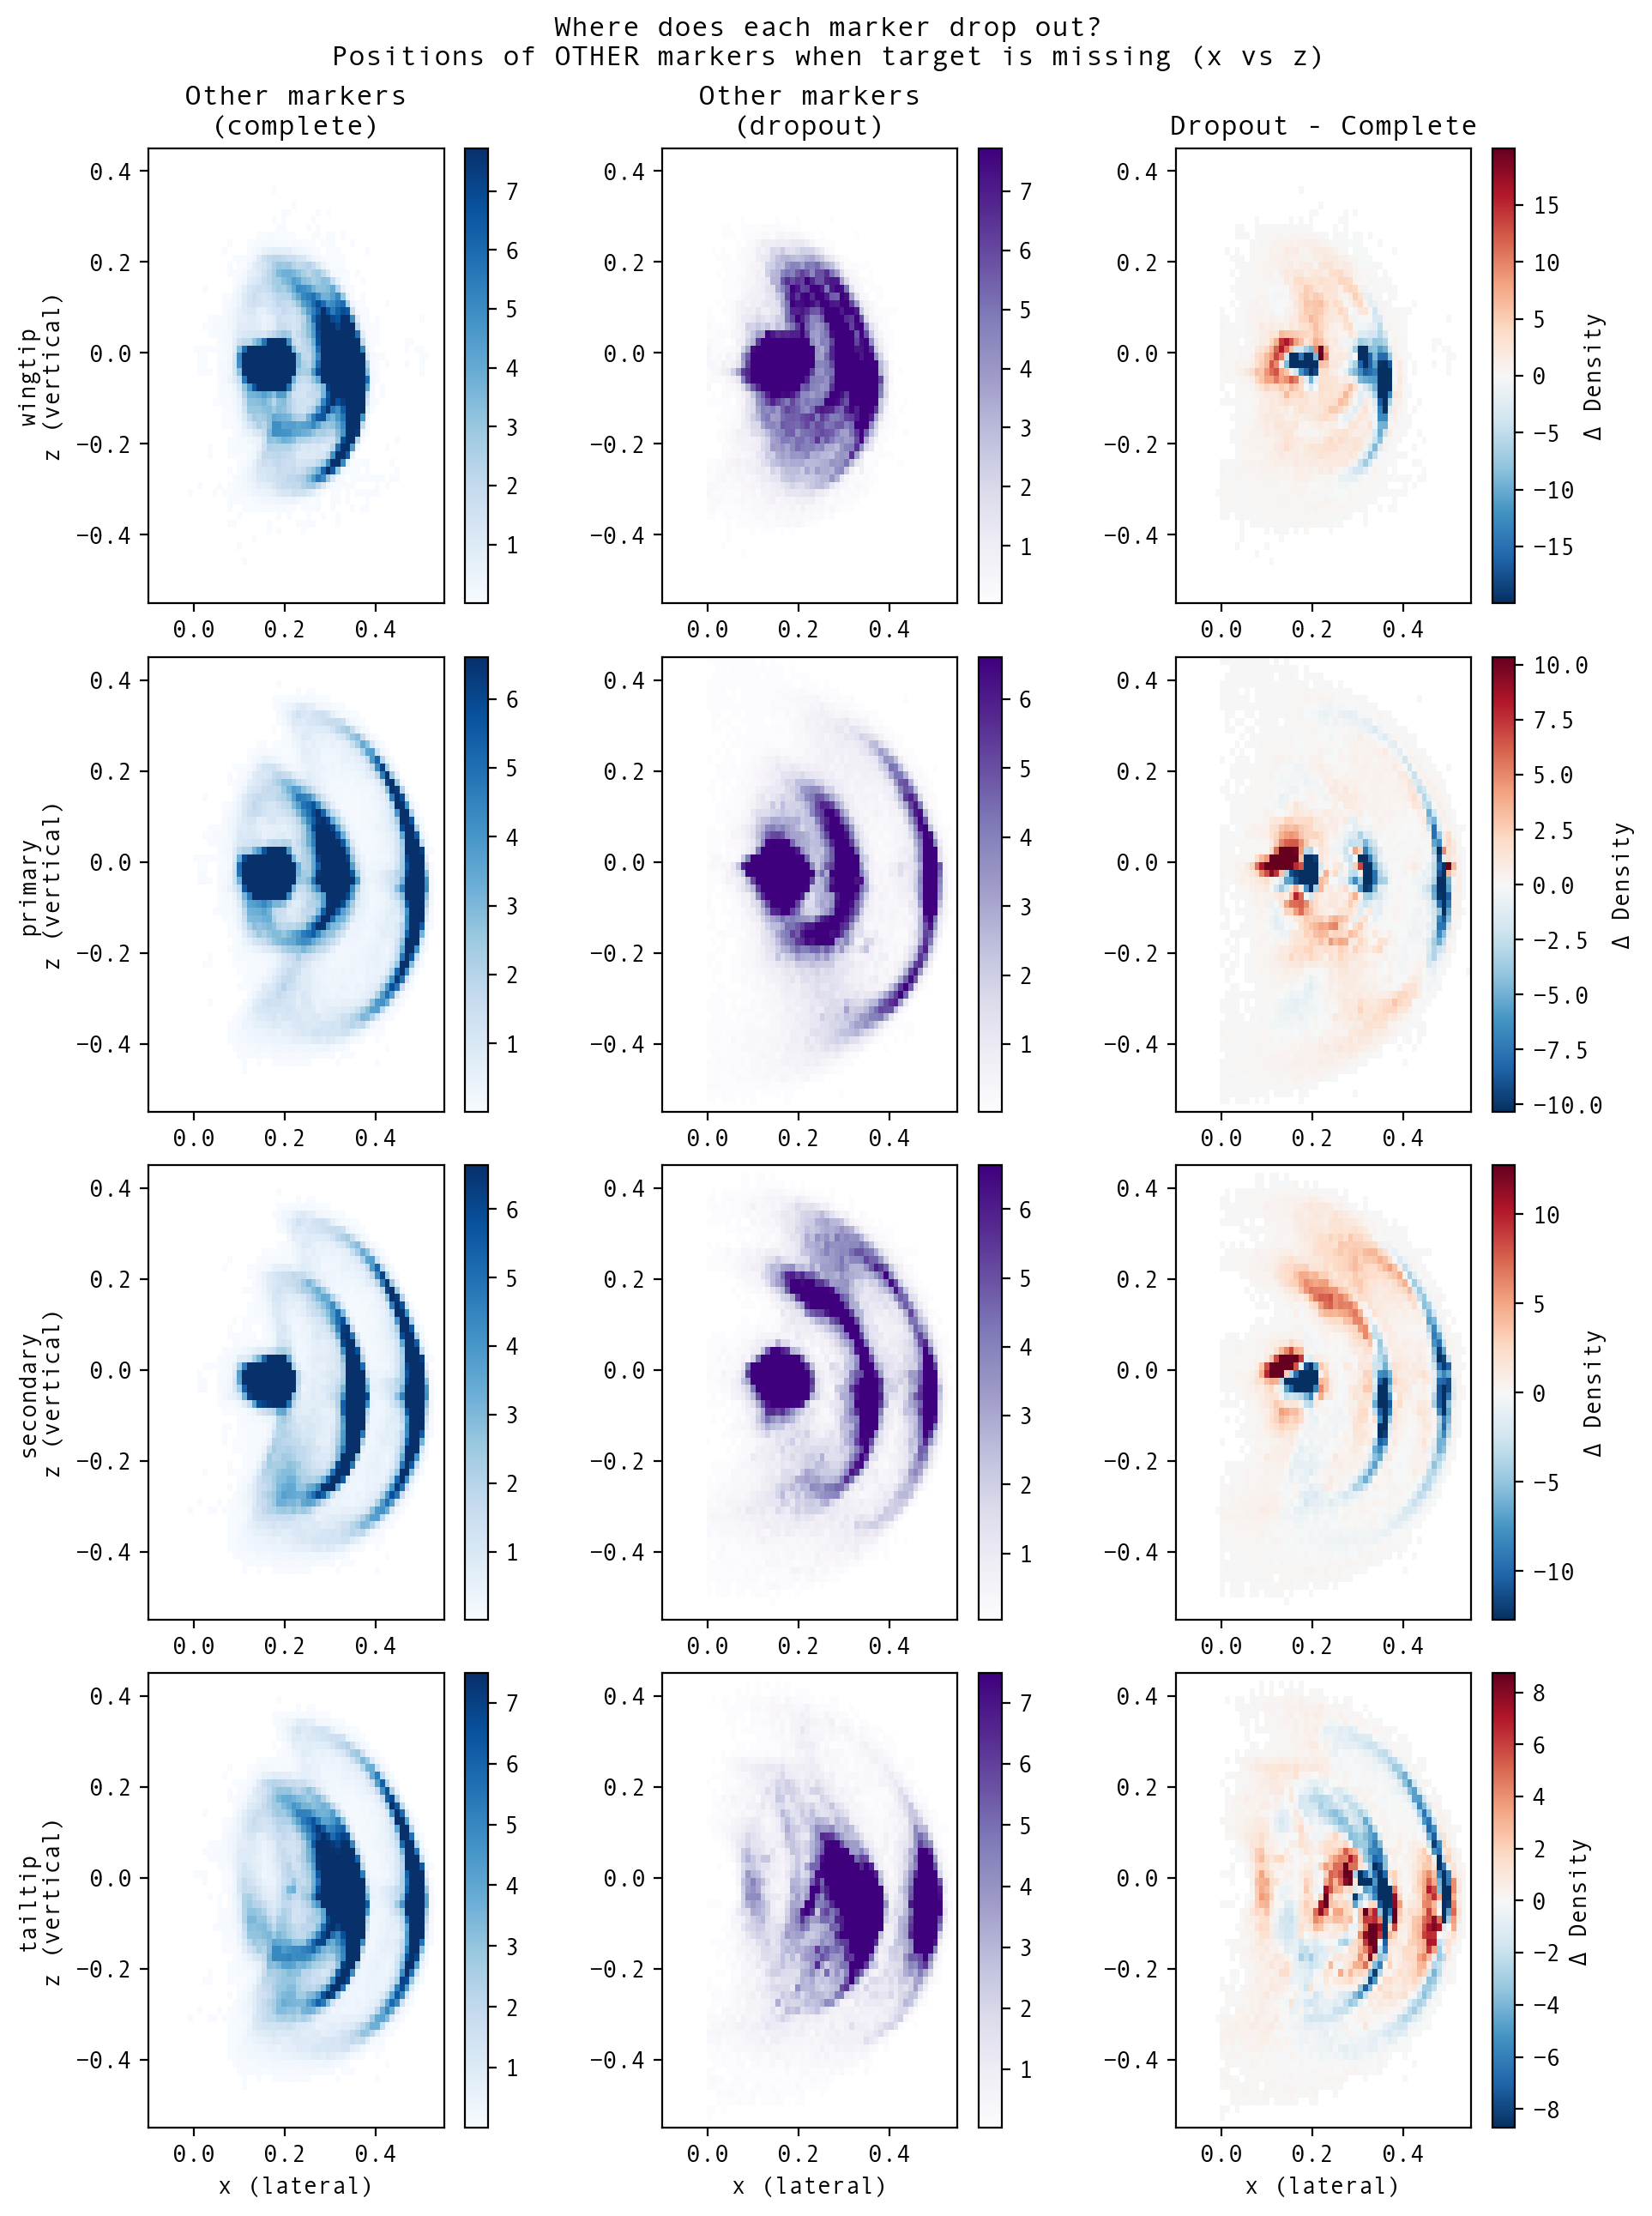

In [18]:
# --- Dropout positions: x vs z ---
fig_drop_xz = plot_dropout_positions(
    complete_unilateral, partial_unilateral, MARKER_NAMES,
    coord_a=0, coord_b=2,
    label_a='x (lateral)', label_b='z (vertical)',
    suptitle='Where does each marker drop out?\nPositions of OTHER markers when target is missing (x vs z)',
)
save_figure(fig_drop_xz, str(FIGURE_DIR / 'S15_dropout_positions_xz.pdf'))
plt.show()

wingtip missing (others present): 57,861 frames
primary missing (others present): 105,957 frames
secondary missing (others present): 60,376 frames
tailtip missing (others present): 44,817 frames
Saved: ../../figures/supplementary/S15_dropout_positions_xy.pdf


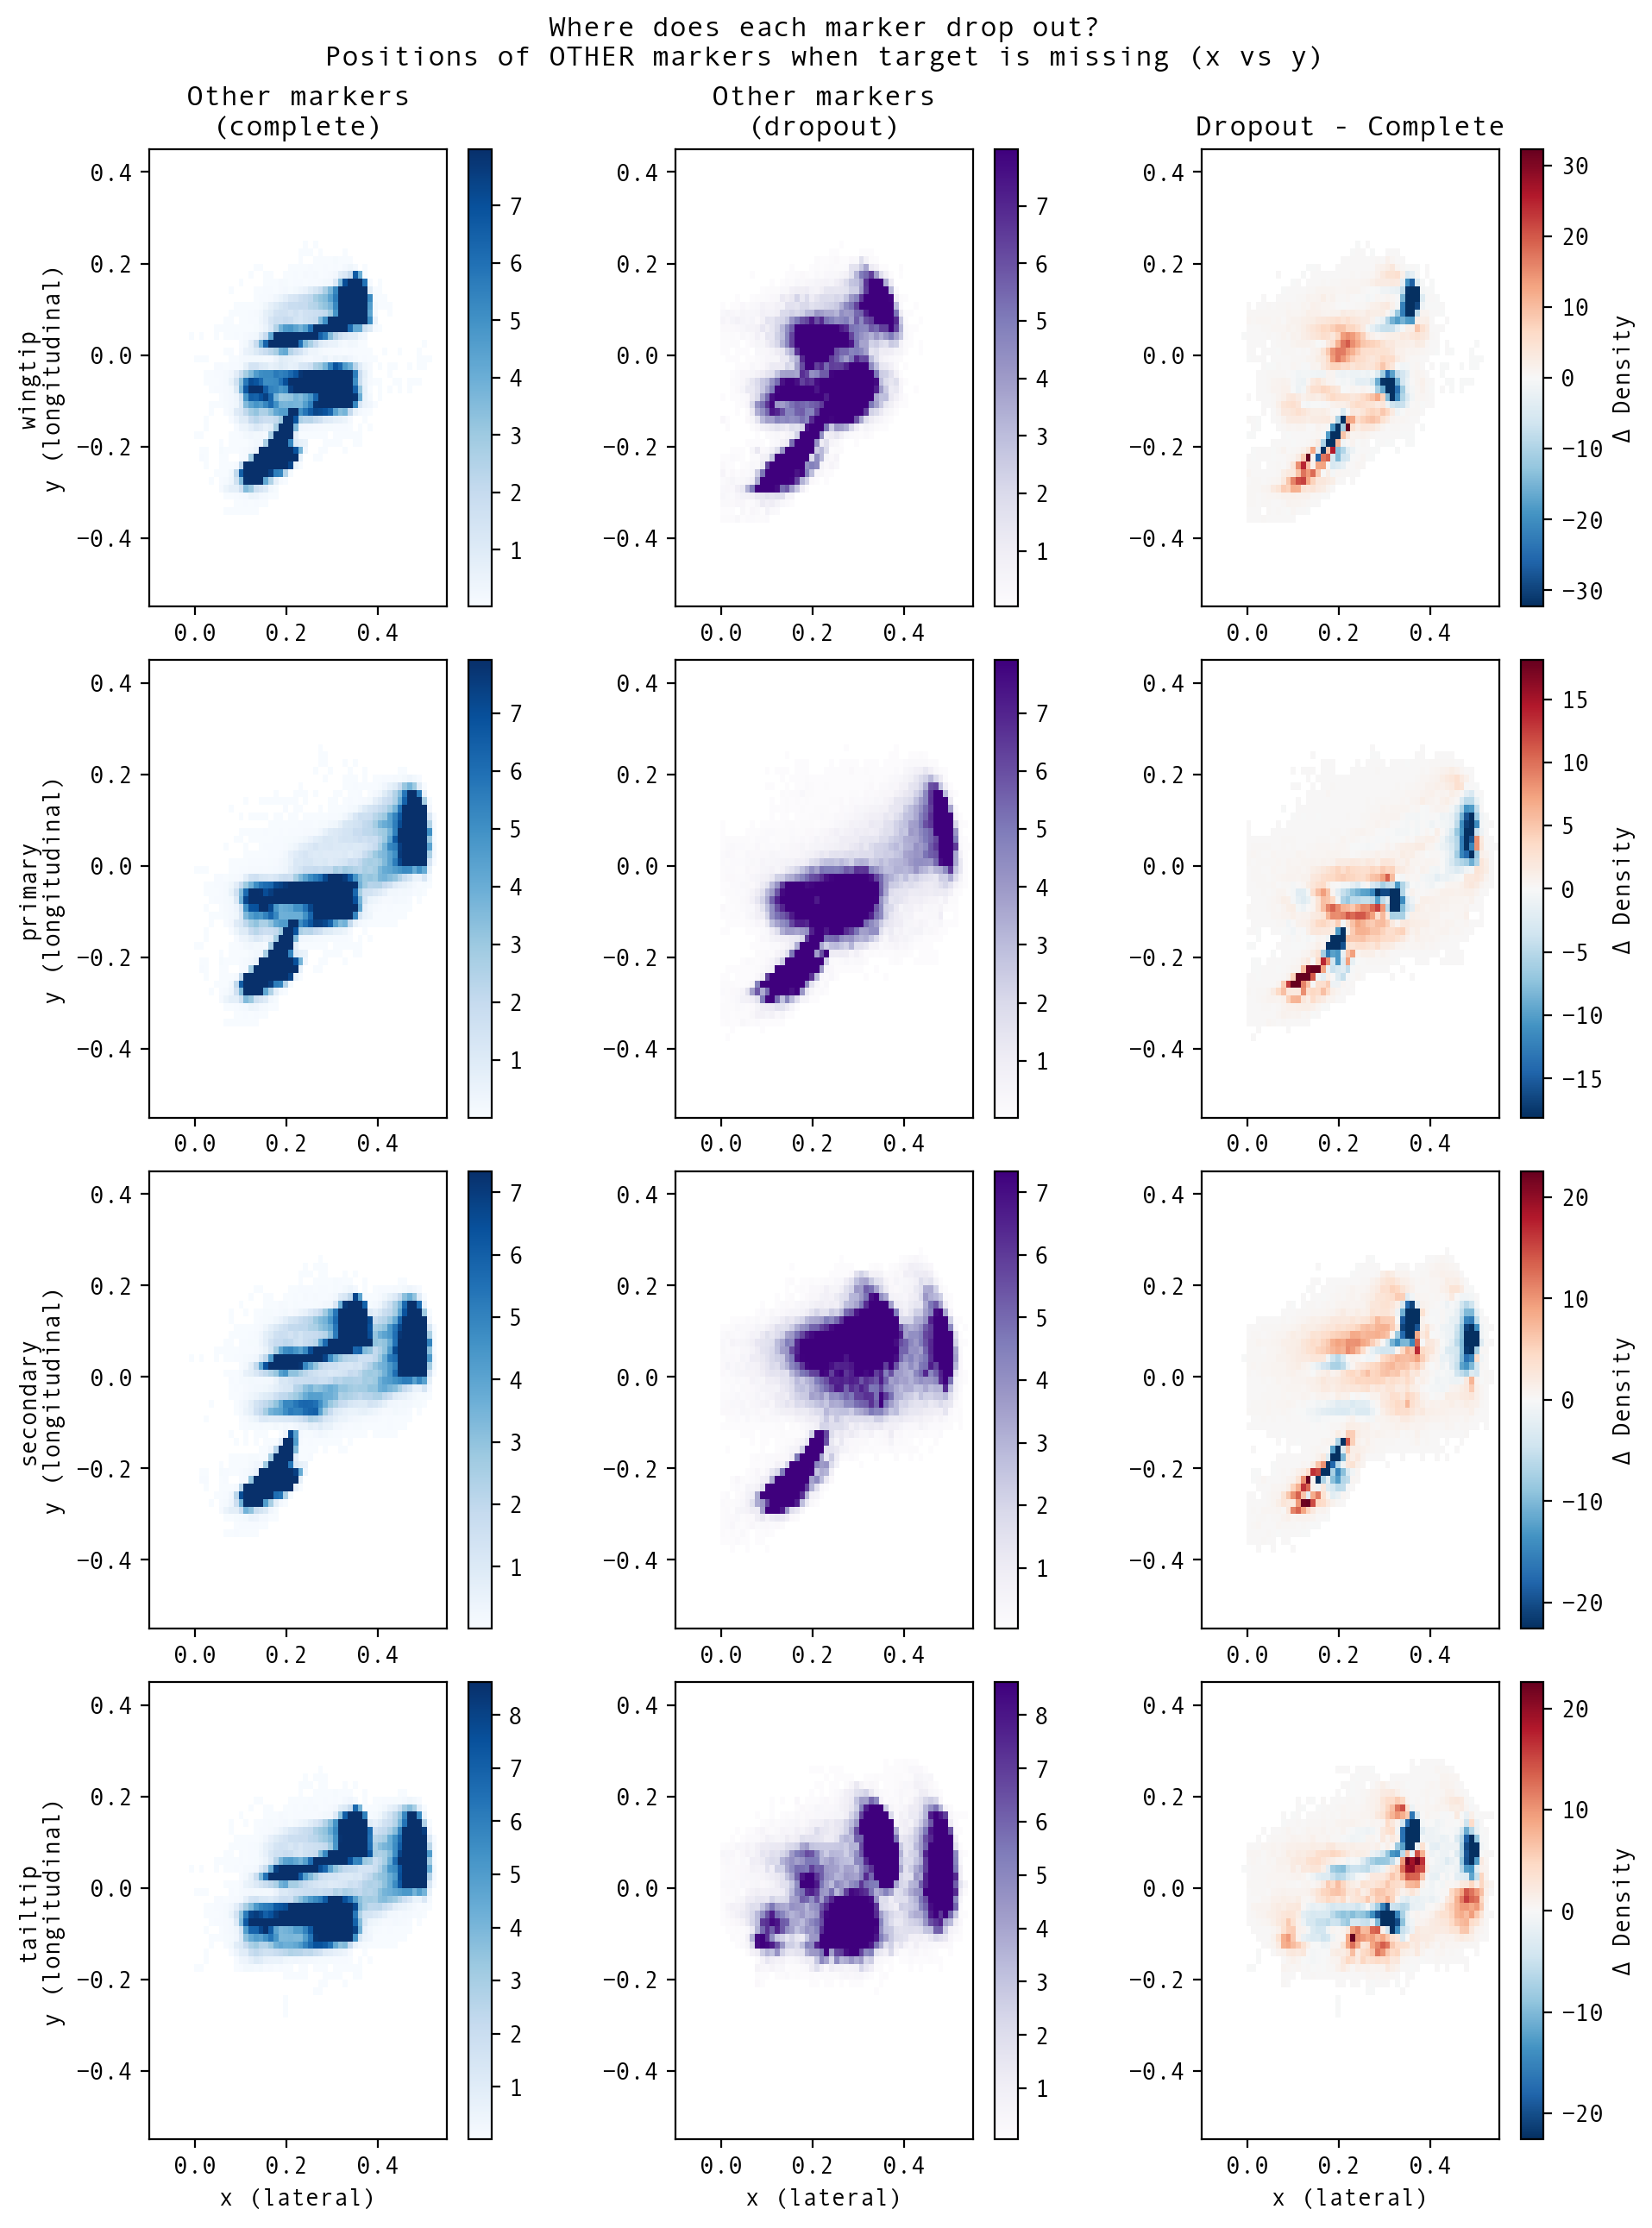

In [19]:
# --- Dropout positions: x vs y ---
fig_drop_xy = plot_dropout_positions(
    complete_unilateral, partial_unilateral, MARKER_NAMES,
    coord_a=0, coord_b=1,
    label_a='x (lateral)', label_b='y (longitudinal)',
    suptitle='Where does each marker drop out?\nPositions of OTHER markers when target is missing (x vs y)',
)
save_figure(fig_drop_xy, str(FIGURE_DIR / 'S15_dropout_positions_xy.pdf'))
plt.show()

**Interpretation.** Marker dropout is posture-dependent, not random. When the wingtip is missing, the remaining markers show the wing in a more folded configuration -- distal feather markers tuck behind the body during deep wingbeats. When the tailtip is missing, the remaining wing markers show more extreme tail deflections. This confirms that certain wing configurations preferentially lose markers, and the complete-marker subset undersamples these extreme postures.

## §15.5 Summary & Limitations

| Test | Question | Finding |
|------|----------|---------|
| **Flight-phase CEV** | Does sampling bias inflate variance concentration? | CEV₄ is highest in flapping-dominated phases and lowest in gliding; the combined 96.3% is pulled down by gliding, not inflated |
| **Density comparison** | Do complete and partial frames occupy the same coordinate space? | Complete frames overrepresent gliding configurations by 19–26 pp; partial frames populate folded-wing regions more uniformly |
| **Occlusion-conditioned PCA** | Do naturally occluded frames have a different morphing subspace? | Modes 1–2 cosines > 0.99 for all markers; same subspace regardless of occlusion |
| **Projection validation** | Can we trust PC scores estimated from partial markers? | Correlations > 0.99 (1 marker masked), > 0.96 (2 markers masked); no systematic bias |
| **Coverage comparison** | Do partial frames visit new regions that complete frames miss? | 35–48% of bins are partial-only, but only 1.6–2.7% of partial frames fall in those novel regions; bias is primarily in density |
| **Matrix completion** | Does imputing missing markers change the PCA? | Modes 1–3 cosines > 0.99; CEV₄ preserved; MICE imputation validates low-rank structure |
| **Dropout rates** | Which markers disappear and how often? | Distal markers (wingtip, primary) drop most; co-dropout reflects shared postural cause |


**Key conclusion:** The complete-marker dataset undersamples folded-wing during flapping, but the morphospace structure is identical regardless of marker visibility. The bias affects sampling density, not the PCA results.

**Limitations not addressed here:**

- **Ghost markers** -- spurious reflections that create phantom marker detections -- are a known motion-capture artefact but are not formally tested in this analysis.
- **Temporal structure of dropout** -- whether markers tend to disappear for long stretches or flicker on and off is not explored here (see NB06 §14.3 for temporal autocorrelation of the complete dataset).
- **Mislabelling detection** -- a systematic analysis of mislabelling patterns and their impact on the PCA is not included here (see NB06 for test exploring the impact of mislabelling).